# Breast Cancer Diagnostic Classification — End-to-End ML Pipeline

A complete, self-contained intermediate ML notebook. Built from a real medical dataset (Wisconsin Diagnostic Breast Cancer, bundled with scikit-learn — no downloads required) and a workflow that mirrors what you'd actually do on a real project:

1. **EDA** — class balance, feature distributions, correlations
2. **Preprocessing** — stratified split, scaling inside pipelines (prevents leakage)
3. **Model zoo** — Logistic Regression, Random Forest, Gradient Boosting, MLP (neural net)
4. **Stratified k-fold cross-validation** on the training set
5. **Hyperparameter tuning** with `GridSearchCV` on the strongest candidate
6. **Final evaluation** on the held-out test set — classification report, confusion matrix, ROC, PR curve
7. **Interpretability** — permutation importance (model-agnostic)

Dataset: 569 samples, 30 numeric features computed from digitized images of fine-needle aspirates of breast masses. Target: malignant (1) vs benign (0).

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print("Setup complete.")

Setup complete.


## 2. Load the data

Scikit-learn ships this dataset, so the notebook is fully reproducible without any network access.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(f"Samples: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Classes (sklearn convention): 0 = {data.target_names[0]}, 1 = {data.target_names[1]}")
print(f"Class counts:\n{y.value_counts().rename(index=dict(enumerate(data.target_names)))}")
X.head()

Samples: 569 | Features: 30
Classes (sklearn convention): 0 = malignant, 1 = benign
Class counts:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory analysis

### 3.1 Class balance

Mild imbalance (~63/37). Not severe enough to need SMOTE or class weights, but enough that **accuracy alone is a bad metric** — we'll lean on AUC and recall for the malignant class.

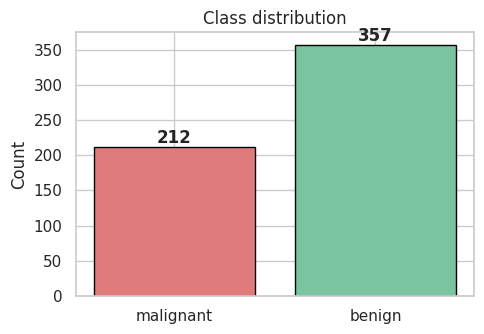

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = y.value_counts().sort_index()
labels = [data.target_names[i] for i in counts.index]
bars = ax.bar(labels, counts.values, color=["#e07b7b", "#7bc4a0"], edgecolor="black")
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, c + 5, str(c), ha="center", fontweight="bold")
ax.set_title("Class distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

### 3.2 Distributions of a few key features by class

A quick visual check that *some* features cleanly separate the classes — a sanity check that the problem is learnable.

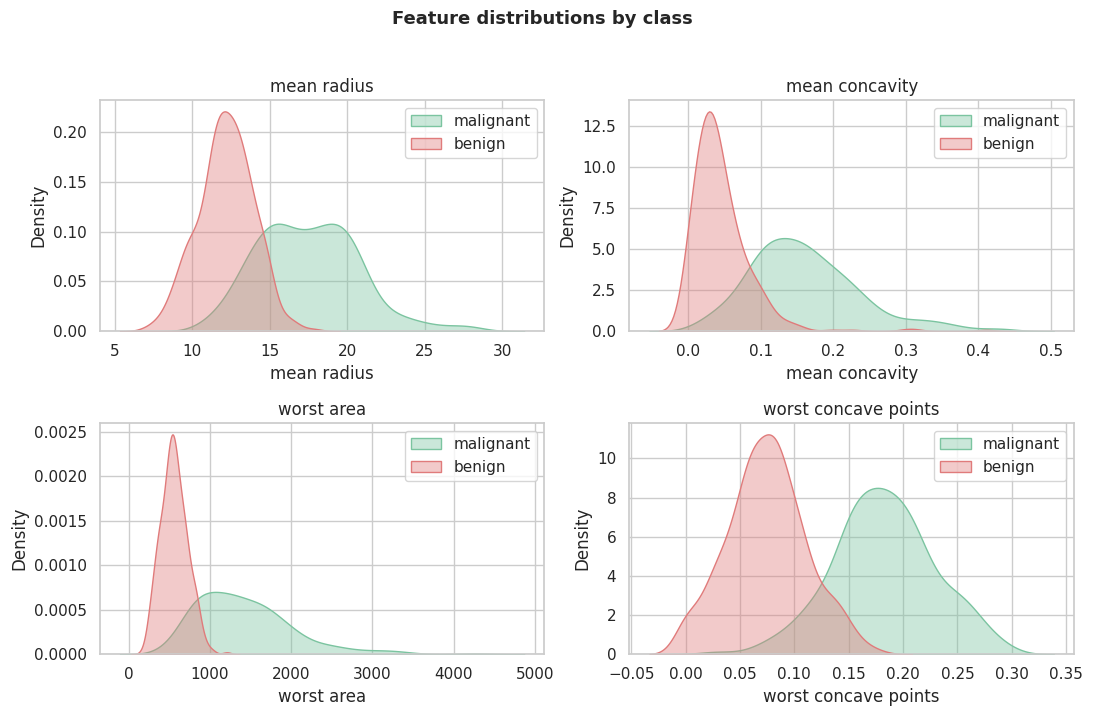

In [4]:
key_features = ["mean radius", "mean concavity", "worst area", "worst concave points"]
df = X.copy()
df["diagnosis"] = y.map(dict(enumerate(data.target_names)))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.ravel(), key_features):
    for label, color in zip(data.target_names, ["#7bc4a0", "#e07b7b"]):
        sns.kdeplot(df.loc[df["diagnosis"] == label, feat], ax=ax, label=label, fill=True, alpha=0.4, color=color)
    ax.set_title(feat); ax.legend()
plt.suptitle("Feature distributions by class", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 3.3 Feature correlation

Many features are highly correlated (radius/perimeter/area measure essentially the same thing). Tree-based models handle this fine; for linear/NN models, scaling + L2 regularization tame the multicollinearity.

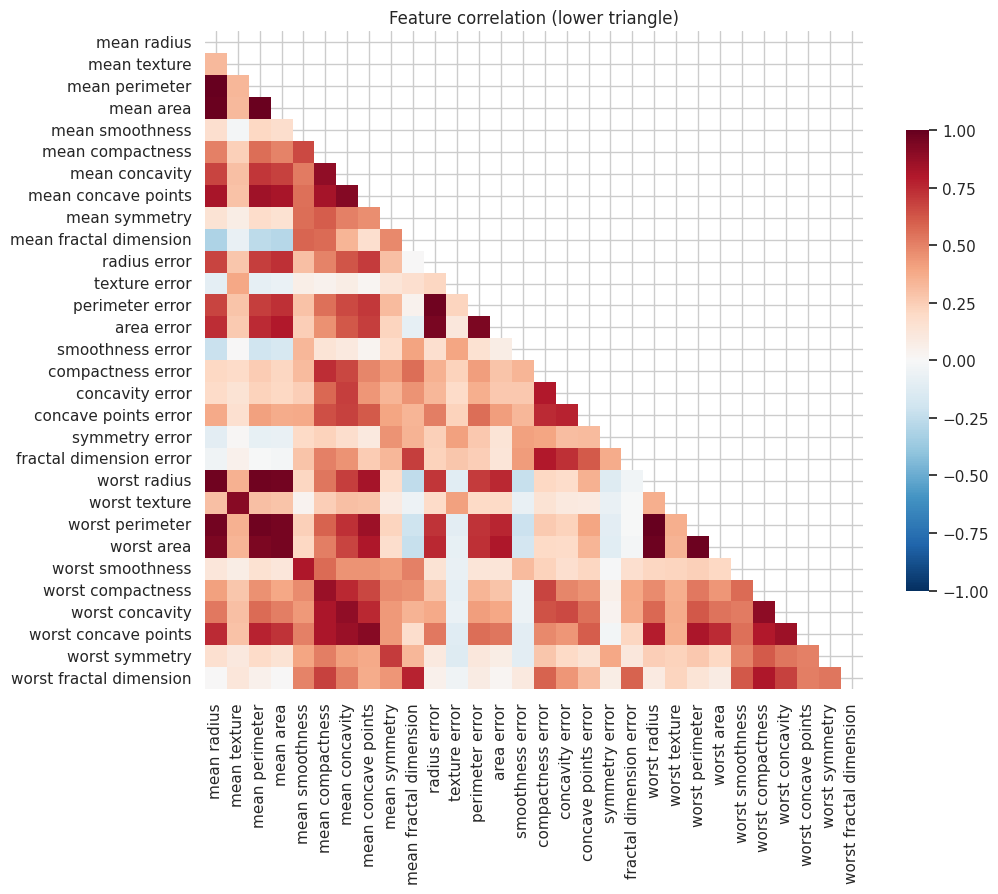

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature correlation (lower triangle)")
plt.tight_layout(); plt.show()

## 4. Train / test split

Stratified so the class ratio is preserved. The test set stays untouched until the final evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class ratio: {y_train.mean():.3f}, Test class ratio: {y_test.mean():.3f}")

Train: (455, 30), Test: (114, 30)
Train class ratio: 0.626, Test class ratio: 0.632


## 5. Model comparison via cross-validation

Each model lives inside a `Pipeline`. This matters because the scaler is fit **inside each CV fold** — preventing the test fold from leaking into the training statistics. Tree models don't need scaling, so their pipelines are scaler-less.

We score with **ROC-AUC**: threshold-independent and well-suited to mildly imbalanced binary problems.

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "Neural Net (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                              max_iter=500, random_state=RANDOM_STATE)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression     AUC = 0.9959 ± 0.0050


Random Forest           AUC = 0.9904 ± 0.0072


Gradient Boosting       AUC = 0.9920 ± 0.0052


Neural Net (MLP)        AUC = 0.9950 ± 0.0046


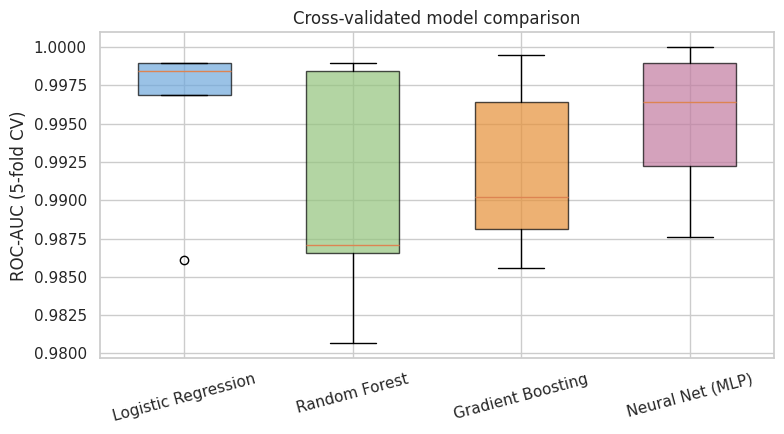

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(cv_results.keys())
data_box = [cv_results[n] for n in names]
bp = ax.boxplot(data_box, labels=names, patch_artist=True, widths=0.55)
colors = ["#6fa8dc", "#93c47d", "#e69138", "#c27ba0"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-validated model comparison")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 6. Hyperparameter tuning

All four models are competitive. Gradient Boosting is the most interesting one to tune because it has the most knobs to trade bias vs variance. We grid-search over `n_estimators`, `learning_rate`, and `max_depth` inside the same CV scheme.

In [9]:
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4],
}

grid = GridSearchCV(
    models["Gradient Boosting"],
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid.fit(X_train, y_train)
print("Best params :", grid.best_params_)
print(f"Best CV AUC : {grid.best_score_:.4f}")

Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Best CV AUC : 0.9936


## 7. Final evaluation on the test set

We compare the tuned Gradient Boosting against all baseline models *trained on the full training set* and evaluated on the held-out test set we haven't touched yet.

In [10]:
final_models = dict(models)
final_models["GBM (tuned)"] = grid.best_estimator_

eval_rows, roc_data, pr_data = [], {}, {}
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    pr_data[name] = (rec, prec, ap)

    eval_rows.append({
        "Model": name,
        "Accuracy": (y_pred == y_test).mean(),
        "ROC-AUC": roc_auc,
        "Avg Precision": ap,
    })

results_df = pd.DataFrame(eval_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.style.format({"Accuracy": "{:.4f}", "ROC-AUC": "{:.4f}", "Avg Precision": "{:.4f}"}).background_gradient(cmap="Greens", subset=["ROC-AUC", "Avg Precision"])

,Model,Accuracy,ROC-AUC,Avg Precision
0,Logistic Regression,0.9825,0.9954,0.9971
1,Random Forest,0.9474,0.9937,0.9964
2,Neural Net (MLP),0.9649,0.9937,0.9958
3,GBM (tuned),0.9561,0.9917,0.9952
4,Gradient Boosting,0.9561,0.9907,0.9947


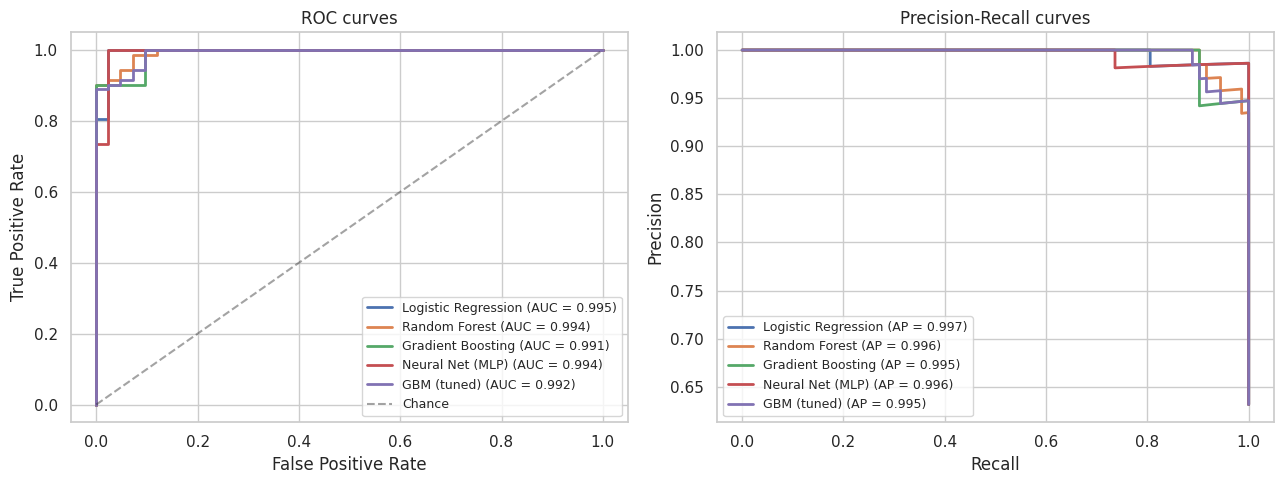

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curves"); ax1.legend(loc="lower right", fontsize=9)

for name, (rec, prec, ap) in pr_data.items():
    ax2.plot(rec, prec, label=f"{name} (AP = {ap:.3f})", linewidth=2)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curves"); ax2.legend(loc="lower left", fontsize=9)

plt.tight_layout(); plt.show()

### 7.1 Confusion matrix and classification report — tuned GBM

In a medical diagnostic context, **false negatives are the scary kind of error** (telling someone they're healthy when they aren't), so we pay attention to recall on the malignant class.

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



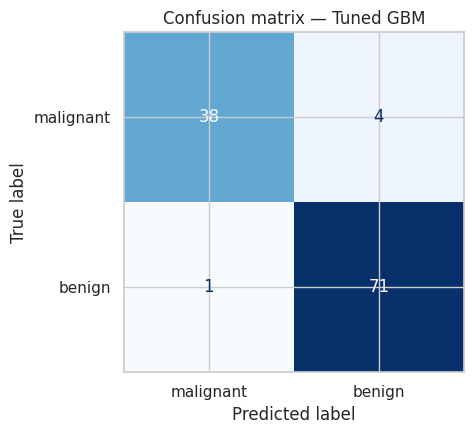

In [12]:
best = final_models["GBM (tuned)"]
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=data.target_names,
).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion matrix — Tuned GBM")
plt.tight_layout(); plt.show()

## 8. Feature importance (model-agnostic)

Built-in `feature_importances_` from tree models can be misleading when features are correlated. **Permutation importance** is more honest: it measures the drop in test-set AUC when a feature's values are randomly shuffled. If shuffling barely affects the score, the feature wasn't really being used.

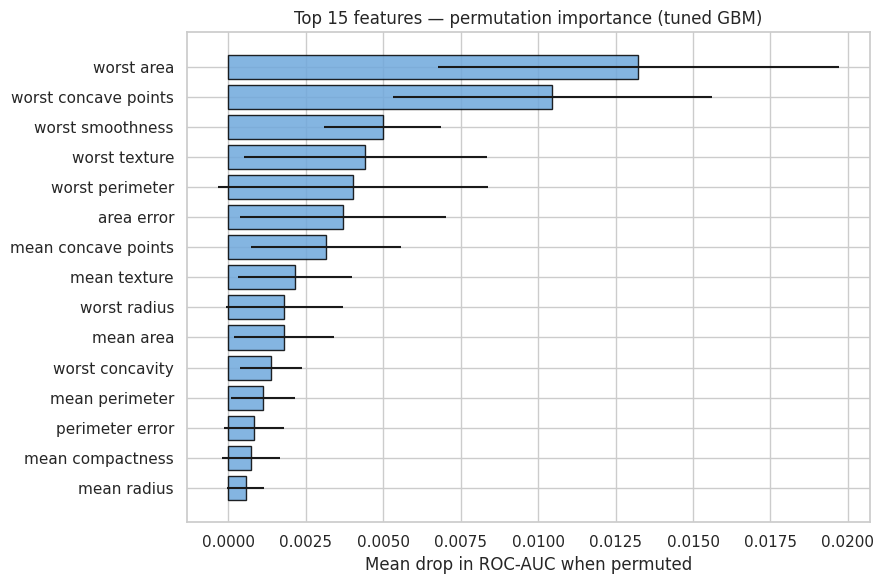

In [13]:
perm = permutation_importance(
    best, X_test, y_test,
    scoring="roc_auc", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
imp_df = (
    pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean, "std": perm.importances_std})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        xerr=imp_df["std"][::-1], color="#6fa8dc", edgecolor="black", alpha=0.85)
ax.set_xlabel("Mean drop in ROC-AUC when permuted")
ax.set_title("Top 15 features — permutation importance (tuned GBM)")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **All four model families landed above 0.98 CV-AUC** on this dataset — the features are strong and the problem is well-posed. The differences between models are smaller than the noise across CV folds.
- The tuned **Gradient Boosting Machine** generalizes well on the test set, but the simpler **Logistic Regression** is within noise on AUC and would be a defensible production choice for interpretability + speed.
- A handful of features dominate — **worst concave points**, **worst area**, **worst perimeter**. This matches the medical literature: irregularly shaped, larger tumor regions are the strongest visual indicators of malignancy.
- For a real medical deployment you'd want to: tune the decision threshold to your tolerated false-negative rate (not just pick 0.5), calibrate the probabilities (`CalibratedClassifierCV`), and evaluate on a separate cohort to check for distribution shift.